#### RS pyramidal neuron

Autapse seems to increase the firing frequency of the neuron marginally. There are some minor differences in the transient behaviour of the neuron on its way to equilibrium.

In [1]:
import sys
sys.path.append("..\\") # parent directory
from AQUA_general import AQUA
from batchAQUA_general import batchAQUA
from stimulus import *
from plotting_functions import *
from phase_response import *


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


100%|██████████| 199999/199999 [00:02<00:00, 83495.51it/s]


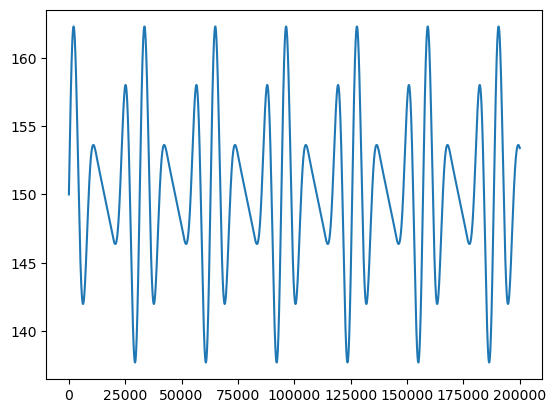

In [ ]:
# regular spiking neuron
RS = {'name': 'RS', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.0, 'f': 0.0, 'tau': 0.0}

RS_a = {'name': 'RS_a', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
    'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 150.0, 'tau': 2.0}

T = 2  #s
dt = 0.01 # ms
N_iter = int(1000*T/dt)

x_ini = np.array([-80, 0, 0])
t_ini = 0.0

N_neurons = 200
I_range = np.linspace(0, 700, N_neurons)

neuron = AQUA(RS)
neuron.Initialise(x_ini, t_ini)

neuron_aut = AQUA(RS_a)
neuron_aut.Initialise(x_ini, t_ini)


y_0 = 0
delay = 300
I_end = 400
#I_inj = ramp(N_iter, dt, y_0, delay, I_end)


I_h = 400
#I_inj = step_current(N_iter, dt, y_0, delay, I_h)

I_inj = superposed_sinusoid(N_iter, dt) + 150
plt.plot(I_inj)


X, T, spikes = neuron.update_RK2(dt, N_iter, I_inj)
ISI = np.round(np.diff(spikes), decimals = 4)
X2, T, spikes_2 = neuron_aut.update_RK2(dt, N_iter, I_inj)
ISI_2 = np.round(np.diff(spikes_2), decimals = 4)

(200000,)


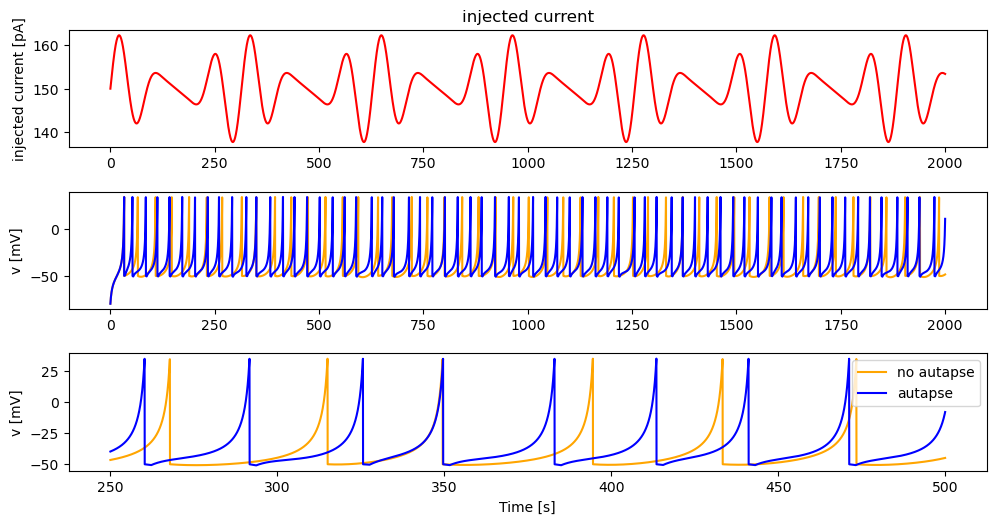

In [3]:
print(np.shape(X[0, :]))
split = np.arange(25000, 50000)
fig, ax = compare_trains(X[0, :], X2[0, :], T, I_inj, indices = split)

plt.show()

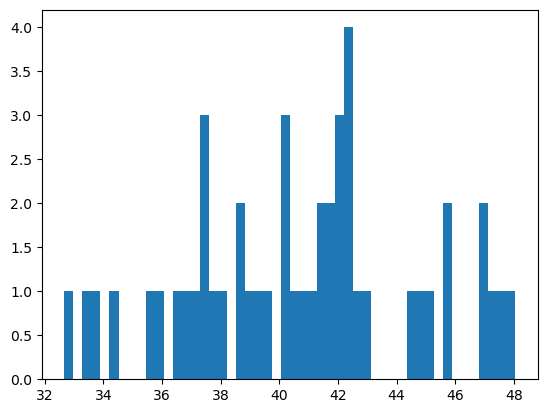

In [4]:
plt.hist(ISI, bins = 50)
plt.show()

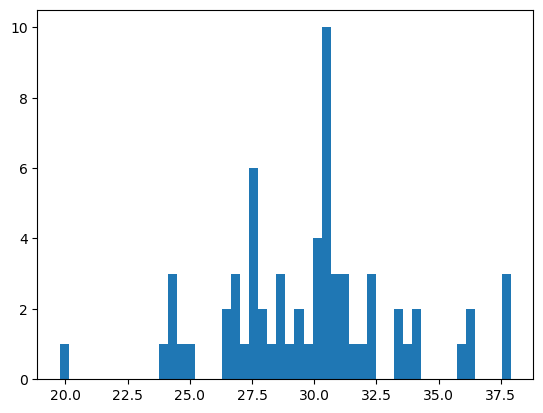

In [5]:
plt.hist(ISI_2, bins = 50)
plt.show()

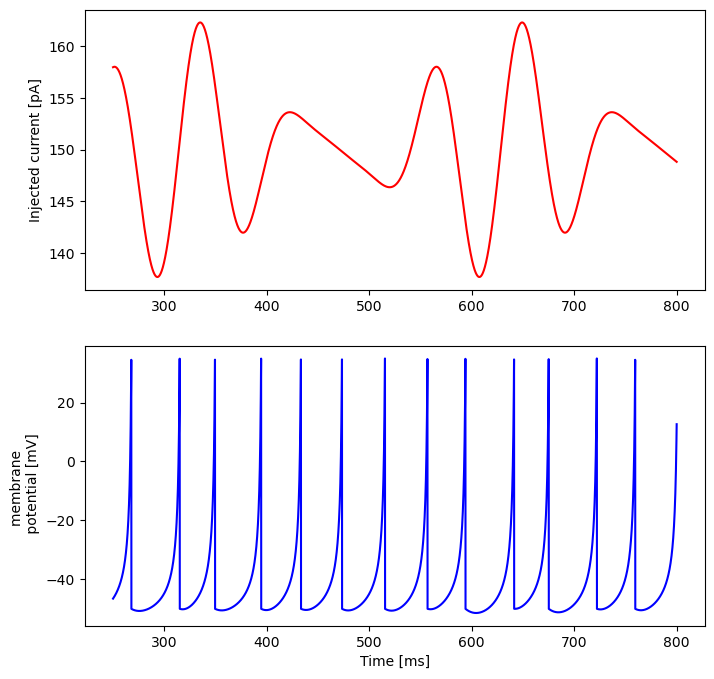

In [6]:
fig, ax = plot_potential_versus_injected(X, T, I_inj, split = np.arange(25000, 80000))
plt.show()

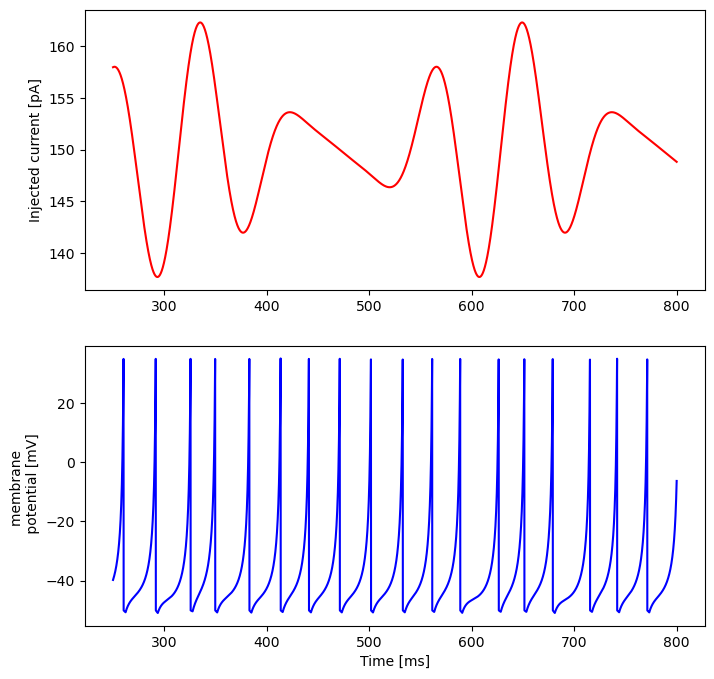

In [7]:
fig, ax = plot_potential_versus_injected(X2, T, I_inj, split = np.arange(25000, 80000))
plt.show()

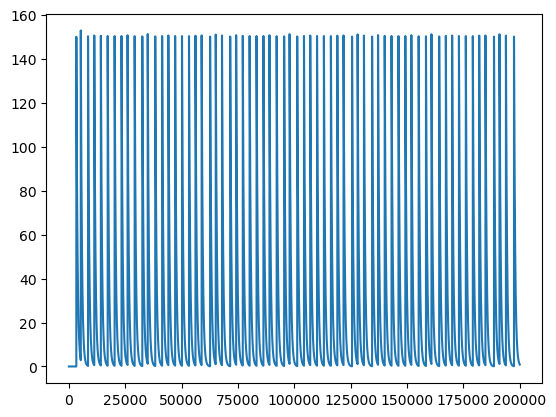

In [8]:
plt.plot(X2[2, :])